# VQA Tiếng Việt — Hướng A (Fully Fixed)
**Image Encoder:** EfficientNet-B2 · **Text Encoder:** PhoBERT-base  
**Decoder A1:** LSTM · **Decoder A2:** Transformer  
**Dataset:** `dung3008/vqa-food-vietnamese` · **Drive:** `MyDrive/VQA_A`



In [ ]:
# CELL 1 — Cài đặt thư viện


!pip install transformers==4.40.0 timm evaluate \
             rouge-score bert-score sacrebleu sacremoses \
             datasets accelerate -q

print('✅ Cài đặt hoàn tất!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ Cài đặt hoàn tất!


In [ ]:
# CELL 2 — Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = '/content/drive/MyDrive/VQA_A'

for sub in ['data/images', 'checkpoints', 'results']:
    os.makedirs(f'{PROJECT_DIR}/{sub}', exist_ok=True)

print('✅ Drive đã mount.')
print('📁 Project dir:', PROJECT_DIR)

Mounted at /content/drive
✅ Drive đã mount.
📁 Project dir: /content/drive/MyDrive/VQA_A


In [ ]:
# CELL 3 — Kiểm tra GPU

import torch

print('GPU :', torch.cuda.get_device_name(0))
print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
print('CUDA:', torch.version.cuda)
print('AMP ready:', torch.cuda.is_available())

GPU : Tesla T4
VRAM: 15.6 GB
CUDA: 12.8
AMP ready: True


In [ ]:
# CELL 4 — Import thư viện


import os, json, math, random, warnings
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

import torchvision.transforms as transforms
import timm
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('✅ Imports xong. Device:', DEVICE)

✅ Imports xong. Device: cuda


In [ ]:
# CELL 5 — Cấu hình dự án

class Config:
    # --- Đường dẫn ---
    PROJECT_DIR   = '/content/drive/MyDrive/VQA_A'
    IMAGE_DIR     = f'{PROJECT_DIR}/data/images'

    # --- Dữ liệu ---
    MAX_Q_LEN     = 64
    MAX_A_LEN     = 10
    IMG_SIZE      = 260
    TRAIN_RATIO   = 0.8
    VAL_RATIO     = 0.1

    # --- Mô hình ---
    IMG_FEAT_DIM  = 1408
    IMG_SPATIAL_C = 1408
    TXT_FEAT_DIM  = 768     # PhoBERT-base
    FUSION_DIM    = 512
    LSTM_HIDDEN   = 512
    LSTM_LAYERS   = 2
    TF_HEADS      = 8
    TF_LAYERS     = 4
    DROPOUT       = 0.3

    # --- Training ---
    BATCH_SIZE      = 16
    EPOCHS          = 30
    LR              = 3e-4
    LR_BACKBONE     = 1e-5
    WARMUP_STEPS    = 100
    GRAD_CLIP       = 1.0
    PATIENCE        = 10
    UNFREEZE_EPOCH  = 10
    PERIODIC_SAVE   = 5

    # --- Token đặc biệt ---
    PAD_TOKEN = '<PAD>'   # id = 0
    SOS_TOKEN = '<SOS>'   # id = 1
    EOS_TOKEN = '<EOS>'   # id = 2
    UNK_TOKEN = '<UNK>'   # id = 3

cfg = Config()
print('✅ Config loaded.')

✅ Config loaded.


In [ ]:
# CELL 6 — Đăng nhập HuggingFace


from huggingface_hub import login
from getpass import getpass

HF_TOKEN = getpass('🔑 Nhập HuggingFace Token: ')
login(token=HF_TOKEN, add_to_git_credential=False)
print('✅ Đã đăng nhập HuggingFace')

🔑 Nhập HuggingFace Token: ··········
✅ Đã đăng nhập HuggingFace


In [ ]:
# CELL 7 — Tải dataset từ HuggingFace


import shutil
from huggingface_hub import snapshot_download

DRIVE_DATA_DIR = f'{cfg.PROJECT_DIR}/data'
IMAGE_DIR      = cfg.IMAGE_DIR
CACHE_FLAG     = f'{DRIVE_DATA_DIR}/.dataset_ready'


def hf_to_list(hf_split):
    # [FIX BUG #A] Đọc đúng field 'image_path'
    result = []
    for row in hf_split:
        result.append({
            'image_id':      row['image_path'],
            'question':      row['question'],
            'answer':        row['answer'],
            'question_type': row.get('question_type', ''),
            'answer_type':   row.get('answer_type', ''),
            'dish':          row.get('dish', ''),
        })
    return result



def filter_existent_images(data_list, split_name):
    before   = len(data_list)
    filtered = [x for x in data_list
                if os.path.exists(os.path.join(IMAGE_DIR, x['image_id']))]
    after = len(filtered)
    if before != after:
        print(f'  ⚠️  [{split_name}] Bỏ {before - after} entry thiếu ảnh ({after}/{before})')
    return filtered


def add_path(x):

    x['image_path'] = os.path.join(IMAGE_DIR, x['image_id'])  # đường dẫn tuyệt đối
    x['image']      = x['image_id']                            # relative (giữ nguyên)
    return x


if os.path.exists(CACHE_FLAG):
    print('✅ Dataset đã có trên Drive — bỏ qua bước tải.')
    with open(f'{DRIVE_DATA_DIR}/train.json', 'r', encoding='utf-8') as f:
        train_data = json.load(f)
    with open(f'{DRIVE_DATA_DIR}/val.json', 'r', encoding='utf-8') as f:
        val_data = json.load(f)
    with open(f'{DRIVE_DATA_DIR}/test.json', 'r', encoding='utf-8') as f:
        test_data = json.load(f)

else:
    print('📥 Đang tải dataset từ HuggingFace (~200MB)...')

    ds = load_dataset('dung3008/vqa-food-vietnamese', token=HF_TOKEN)
    print('✅ Tải xong metadata:', ds)

    train_data = hf_to_list(ds['train'])
    val_data   = hf_to_list(ds['validation'])
    test_data  = hf_to_list(ds['test'])

    hf_dir = snapshot_download(
        repo_id   = 'dung3008/vqa-food-vietnamese',
        repo_type = 'dataset',
        local_dir = '/content/hf_tmp',
        token     = HF_TOKEN,
    )
    print(f'✅ Snapshot → {hf_dir}')

    if os.path.exists(IMAGE_DIR):
        shutil.rmtree(IMAGE_DIR)
    shutil.copytree(os.path.join(hf_dir, 'images'), IMAGE_DIR)
    print(f'🖼️  Images → {IMAGE_DIR}')

    os.makedirs(DRIVE_DATA_DIR, exist_ok=True)
    for name, data in [('train', train_data), ('val', val_data), ('test', test_data)]:
        with open(f'{DRIVE_DATA_DIR}/{name}.json', 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

    open(CACHE_FLAG, 'w').close()
    shutil.rmtree('/content/hf_tmp', ignore_errors=True)
    print('✅ Đã lưu JSON + dọn file tạm.')



# → key 'image_path' luôn có mặt trong mọi sample
train_data = filter_existent_images(train_data, 'train')
val_data   = filter_existent_images(val_data,   'val')
test_data  = filter_existent_images(test_data,  'test')

train_data = [add_path(x) for x in train_data]
val_data   = [add_path(x) for x in val_data]
test_data  = [add_path(x) for x in test_data]

print(f'\n📊 Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')


def check_images(dataset, name, n=50):
    missing = sum(1 for x in dataset[:n] if not os.path.exists(x['image_path']))
    print(f'  {name}: {"✅ OK" if missing == 0 else f"⚠️ thiếu {missing} ảnh"}')

check_images(train_data, 'Train')
check_images(val_data,   'Val')
check_images(test_data,  'Test')

try:
    img = Image.open(train_data[0]['image_path']).convert('RGB')
    print(f'🖼️  Test load ảnh OK: {img.size}')
except Exception as e:
    print('❌ Lỗi load ảnh:', e)

print('\n📌 Sample:')
print(json.dumps({k: v for k, v in train_data[0].items() if k != 'image_path'},
                 ensure_ascii=False, indent=2))

✅ Dataset đã có trên Drive — bỏ qua bước tải.

📊 Train: 12810 | Val: 554 | Test: 584
  Train: ✅ OK
  Val: ✅ OK
  Test: ✅ OK
🖼️  Test load ảnh OK: (256, 256)

📌 Sample:
{
  "image_id": "train/Banh_Beo/3.jpg",
  "question": "trong ảnh là món ăn gì",
  "answer": "bánh bèo",
  "question_type": "recognition",
  "answer_type": "text",
  "dish": "Banh_Beo",
  "image": "train/Banh_Beo/3.jpg"
}


In [ ]:
# CELL 8 — Answer Vocabulary

class AnswerVocab:
    def __init__(self):
        self.word2idx = {
            cfg.PAD_TOKEN: 0,
            cfg.SOS_TOKEN: 1,
            cfg.EOS_TOKEN: 2,
            cfg.UNK_TOKEN: 3,
        }
        self.idx2word  = {v: k for k, v in self.word2idx.items()}
        self.n_words   = 4
        self._unk_count = 0

    def build_from_data(self, answers: list):
        for ans in answers:
            for word in str(ans).strip().lower().split():
                if word not in self.word2idx:
                    self.word2idx[word] = self.n_words
                    self.idx2word[self.n_words] = word
                    self.n_words += 1
        print(f'✅ Vocab size: {self.n_words} từ')

    def encode(self, answer: str) -> list:
        tokens = [cfg.SOS_TOKEN] + str(answer).strip().lower().split() + [cfg.EOS_TOKEN]
        ids = []
        for t in tokens:
            if t not in self.word2idx:
                self._unk_count += 1
            ids.append(self.word2idx.get(t, self.word2idx[cfg.UNK_TOKEN]))
        return ids

    def decode(self, indices: list) -> str:
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, cfg.UNK_TOKEN)
            if word == cfg.EOS_TOKEN:
                break
            if word in (cfg.SOS_TOKEN, cfg.PAD_TOKEN, cfg.UNK_TOKEN):
                continue
            words.append(word)
        return ' '.join(words)

    def report_unk(self):
        print(f'⚠️  Tổng số lần gặp <UNK>: {self._unk_count}')

    def save(self, path):
        with open(path, 'w', encoding='utf-8') as f:
            json.dump({'word2idx': self.word2idx,
                       'idx2word': self.idx2word,
                       'n_words':  self.n_words}, f, ensure_ascii=False, indent=2)

    @classmethod
    def load(cls, path):
        obj = cls()
        with open(path, encoding='utf-8') as f:
            d = json.load(f)
        obj.word2idx = d['word2idx']
        obj.idx2word = {int(k): v for k, v in d['idx2word'].items()}
        obj.n_words  = d['n_words']
        return obj


vocab = AnswerVocab()
vocab.build_from_data([s['answer'] for s in train_data])
vocab.save(f'{cfg.PROJECT_DIR}/checkpoints/vocab.json')
print(f'💾 Vocab → {cfg.PROJECT_DIR}/checkpoints/vocab.json')

from collections import Counter
qtypes = Counter(s.get('question_type', 'unknown') for s in train_data)
print('\n📊 Phân bố question_type (train):')
for qt, cnt in qtypes.most_common():
    print(f'   {qt:20s}: {cnt}')

✅ Vocab size: 760 từ
💾 Vocab → /content/drive/MyDrive/VQA_A/checkpoints/vocab.json

📊 Phân bố question_type (train):
   yes/no              : 4620
   attribute           : 3621
   recognition         : 1473
   counting            : 1032
   spatial             : 1032
   open                : 1032


In [ ]:
# CELL 9 — VQADataset + DataLoaders
# [FIX #6] persistent_workers=True để ổn định trên Colab

class VQADataset(Dataset):
    def __init__(self, samples, vocab, tokenizer, image_dir, transform):
        self.samples   = samples
        self.vocab     = vocab
        self.tokenizer = tokenizer
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]

        # --- Ảnh ---
        # item['image'] = relative path (e.g. 'train/Dish/3.jpg')
        # Luôn load từ string path (data từ JSON không bao giờ là PIL object)
        try:
            img = Image.open(os.path.join(self.image_dir, item['image'])).convert('RGB')
            img = self.transform(img)
        except OSError as e:
            print(f"⚠️  Skipping corrupted: {item['image']}: {e}")
            return None

        # --- Câu hỏi ---
        q_enc = self.tokenizer(
            item['question'],
            max_length=cfg.MAX_Q_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        input_ids      = q_enc['input_ids'].squeeze(0)
        attention_mask = q_enc['attention_mask'].squeeze(0)

        # --- Câu trả lời ---
        ans_ids = self.vocab.encode(str(item['answer']))
        max_len = cfg.MAX_A_LEN + 2
        ans_ids = ans_ids[:max_len]
        ans_ids += [0] * (max_len - len(ans_ids))
        ans_ids = torch.tensor(ans_ids, dtype=torch.long)

        return {
            'image':          img,
            'input_ids':      input_ids,
            'attention_mask': attention_mask,
            'answer_ids':     ans_ids,
            'answer_text':    str(item['answer']),
            'question':       item['question'],
            'question_type':  item.get('question_type', ''),
        }


def get_transform(is_train=True):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if is_train:
        return transforms.Compose([
            transforms.Resize((cfg.IMG_SIZE + 32, cfg.IMG_SIZE + 32)),
            transforms.RandomCrop(cfg.IMG_SIZE),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])


def collate_fn(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(batch)


tokenizer = AutoTokenizer.from_pretrained('vinai/phobert-base')

train_ds = VQADataset(train_data, vocab, tokenizer, cfg.IMAGE_DIR, get_transform(True))
val_ds   = VQADataset(val_data,   vocab, tokenizer, cfg.IMAGE_DIR, get_transform(False))
test_ds  = VQADataset(test_data,  vocab, tokenizer, cfg.IMAGE_DIR, get_transform(False))

train_loader = DataLoader(
    train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_ds, batch_size=1, shuffle=False,
    num_workers=0, collate_fn=collate_fn,
)

print(f'✅ DataLoaders — Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ DataLoaders — Train: 12810 | Val: 554 | Test: 584


In [ ]:
# CELL 10 — Image Encoder: EfficientNet-B2


class ImageEncoder(nn.Module):
    def __init__(self, output_dim=cfg.FUSION_DIM, freeze=True):
        super().__init__()
        self.is_frozen  = freeze
        self.output_dim = output_dim


        self.backbone = timm.create_model(
            'efficientnet_b2', pretrained=True, num_classes=0, global_pool=''
        )


        actual_feat_dim = self.backbone.num_features
        assert actual_feat_dim == cfg.IMG_FEAT_DIM, (
            f'IMG_FEAT_DIM mismatch: cfg={cfg.IMG_FEAT_DIM}, backbone={actual_feat_dim}'
        )

        # Global projection: IMG_FEAT_DIM → FUSION_DIM
        self.proj_global = nn.Sequential(
            nn.Linear(cfg.IMG_FEAT_DIM, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
        )
        # Spatial projection: IMG_FEAT_DIM → FUSION_DIM
        self.proj_spatial = nn.Sequential(
            nn.Linear(cfg.IMG_SPATIAL_C, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
        )


        self.spatial_pos_emb = nn.Parameter(torch.randn(1, 100, output_dim) * 0.02)

        if freeze:
            self._freeze()

    def _freeze(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.is_frozen = True
        print('ImageEncoder: EfficientNet-B2 đã FREEZE')

    def unfreeze_last_blocks(self, n=2):
        blocks = list(self.backbone.blocks.children())
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        self.is_frozen = False
        print(f'ImageEncoder: Đã unfreeze {n} block cuối')

    def _extract(self, images):

        if self.is_frozen:
            with torch.no_grad():
                return self.backbone(images)   # (B, C, H, W)
        return self.backbone(images)

    def forward(self, images):
        feat = self._extract(images)               # (B, C, H, W)
        global_feat = feat.mean(dim=[2, 3])        # (B, C) — avg pool
        return self.proj_global(global_feat)       # (B, FUSION_DIM)

    def forward_spatial(self, images):
        feat = self._extract(images)               # (B, C, H, W)
        B, C, H, W = feat.shape
        n = H * W                                  # thường = 81 với 260×260

        feat = feat.permute(0, 2, 3, 1).reshape(B, n, C)   # (B, n, C)
        projected = self.proj_spatial(feat)                  # (B, n, FUSION_DIM)


        pos = self.spatial_pos_emb[:, :n, :]                 # (1, n, FUSION_DIM)
        return projected + pos                               # (B, n, FUSION_DIM)

In [ ]:
# CELL 11 — Text Encoder: PhoBERT-base


class TextEncoder(nn.Module):
    def __init__(self, output_dim=cfg.FUSION_DIM, freeze=True):
        super().__init__()
        self.is_frozen = freeze
        self.phobert   = AutoModel.from_pretrained('vinai/phobert-base')

        self.proj = nn.Sequential(
            nn.Linear(cfg.TXT_FEAT_DIM, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
        )
        if freeze:
            self._freeze()

    def _freeze(self):
        for p in self.phobert.parameters():
            p.requires_grad = False
        self.is_frozen = True
        print('TextEncoder: PhoBERT đã FREEZE')

    def unfreeze_last_layers(self, n=2):
        for layer in self.phobert.encoder.layer[-n:]:
            for p in layer.parameters():
                p.requires_grad = True
        self.is_frozen = False
        print(f'TextEncoder: Đã unfreeze {n} layer cuối')

    def forward(self, input_ids, attention_mask):
        if self.is_frozen:
            with torch.no_grad():
                out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        else:
            out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)

        # Mean pooling: trung bình các token, bỏ PAD
        hidden      = out.last_hidden_state                  # (B, seq, 768)
        mask        = attention_mask.unsqueeze(-1).float()   # (B, seq, 1)
        summed      = (hidden * mask).sum(dim=1)             # (B, 768)
        counts      = mask.sum(dim=1).clamp(min=1e-9)        # (B, 1)
        mean_pooled = summed / counts                        # (B, 768)
        return self.proj(mean_pooled)                        # (B, FUSION_DIM)

In [ ]:
# CELL 12 — Fusion Module (dùng cho LSTM decoder)

class FusionModule(nn.Module):
    def __init__(self, feat_dim=cfg.FUSION_DIM):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(feat_dim * 2, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(feat_dim, feat_dim),
        )

    def forward(self, img_feat, txt_feat):
        combined = torch.cat([img_feat, txt_feat], dim=-1)
        return self.fusion(combined)

In [ ]:
# CELL 13 — Decoder A1: LSTM


class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256,
                 hidden_dim=cfg.LSTM_HIDDEN, num_layers=cfg.LSTM_LAYERS):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.init_h      = nn.Linear(cfg.FUSION_DIM, hidden_dim * num_layers)
        self.init_c      = nn.Linear(cfg.FUSION_DIM, hidden_dim * num_layers)
        self.lstm        = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            dropout=cfg.DROPOUT if num_layers > 1 else 0,
        )
        self.output_proj = nn.Linear(hidden_dim, vocab_size)
        self.dropout     = nn.Dropout(cfg.DROPOUT)

    def forward(self, fusion_feat, answer_ids=None, teacher_forcing=True):
        batch = fusion_feat.size(0)

        h0 = self.init_h(fusion_feat).view(batch, self.num_layers, self.hidden_dim)
        h0 = h0.permute(1, 0, 2).contiguous()
        c0 = self.init_c(fusion_feat).view(batch, self.num_layers, self.hidden_dim)
        c0 = c0.permute(1, 0, 2).contiguous()

        max_len = cfg.MAX_A_LEN + 1

        if teacher_forcing and answer_ids is not None:
            dec_input = answer_ids[:, :-1]
            embed     = self.dropout(self.embedding(dec_input))
            output, _ = self.lstm(embed, (h0, c0))
            return self.output_proj(output)

        else:

            current    = torch.full((batch, 1), 1, dtype=torch.long, device=fusion_feat.device)
            h, c       = h0, c0
            logits_all = []
            finished   = torch.zeros(batch, dtype=torch.bool, device=fusion_feat.device)

            for _ in range(max_len):
                embed       = self.dropout(self.embedding(current))
                out, (h, c) = self.lstm(embed, (h, c))
                logit       = self.output_proj(out)
                logits_all.append(logit)
                next_token  = logit.argmax(dim=-1).squeeze(-1)   # (batch,)
                finished    = finished | (next_token == 2)        # EOS id = 2
                if finished.all():
                    break
                current = next_token.unsqueeze(-1)

            return torch.cat(logits_all, dim=1)

In [ ]:
# CELL 14 — Decoder A2: Transformer

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=cfg.FUSION_DIM,
                 nhead=cfg.TF_HEADS, num_layers=cfg.TF_LAYERS):
        super().__init__()
        self.embed_dim = embed_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc   = PositionalEncoding(embed_dim, max_len=cfg.MAX_A_LEN + 10)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=embed_dim * 4,
            dropout=cfg.DROPOUT, batch_first=True,
        )
        self.decoder     = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(embed_dim, vocab_size)

    @staticmethod
    def _causal_mask(size, device):
        return torch.triu(torch.ones(size, size, device=device), diagonal=1).bool()

    def forward(self, memory, answer_ids=None, teacher_forcing=True):
        """
        memory: (B, n+1, FUSION_DIM) — concat([txt_feat, spatial_patches])
        """
        batch   = memory.size(0)
        device  = memory.device
        max_len = cfg.MAX_A_LEN + 1

        if teacher_forcing and answer_ids is not None:
            dec_input = answer_ids[:, :-1]
            seq_len   = dec_input.size(1)
            pad_mask  = (dec_input == 0)    # True ở PAD → không attend

            tgt = self.pos_enc(self.embedding(dec_input) * math.sqrt(self.embed_dim))
            out = self.decoder(
                tgt=tgt,
                memory=memory,
                tgt_mask=self._causal_mask(seq_len, device),
                tgt_key_padding_mask=pad_mask,
            )
            return self.output_proj(out)

        else:

            current  = torch.full((batch, 1), 1, dtype=torch.long, device=device)
            outputs  = []
            finished = torch.zeros(batch, dtype=torch.bool, device=device)

            for _ in range(max_len):
                seq_len  = current.size(1)
                pad_mask = (current == 0)
                tgt = self.pos_enc(
                    self.embedding(current) * math.sqrt(self.embed_dim)
                )
                out   = self.decoder(
                    tgt=tgt,
                    memory=memory,
                    tgt_mask=self._causal_mask(seq_len, device),
                    tgt_key_padding_mask=pad_mask,
                )
                logit      = self.output_proj(out[:, -1:, :])    # (B, 1, vocab)
                outputs.append(logit)
                next_token = logit.argmax(dim=-1).squeeze(-1)    # (B,)
                finished   = finished | (next_token == 2)         # EOS id = 2
                if finished.all():
                    break
                current = torch.cat([current, next_token.unsqueeze(-1)], dim=1)

            return torch.cat(outputs, dim=1)

In [ ]:
# CELL 15 — VQAModel hoàn chỉnh

class VQAModel(nn.Module):
    def __init__(self, vocab_size, decoder_type='lstm'):
        super().__init__()
        assert decoder_type in ('lstm', 'transformer')
        self.decoder_type = decoder_type

        self.img_encoder = ImageEncoder(output_dim=cfg.FUSION_DIM, freeze=True)
        self.txt_encoder = TextEncoder(output_dim=cfg.FUSION_DIM,  freeze=True)
        self.fusion      = FusionModule(feat_dim=cfg.FUSION_DIM)

        if decoder_type == 'lstm':
            self.decoder = LSTMDecoder(vocab_size=vocab_size)
        else:
            self.decoder = TransformerDecoder(vocab_size=vocab_size)

        print(f'\nVQAModel: decoder = {decoder_type.upper()}')
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'Tham số trainable: {trainable:,} / {total:,}')

    def forward(self, images, input_ids, attention_mask,
                answer_ids=None, teacher_forcing=True):

        txt_feat = self.txt_encoder(input_ids, attention_mask)   # (B, FUSION_DIM)

        if self.decoder_type == 'lstm':
            # LSTM: global image feature + fusion
            img_feat    = self.img_encoder(images)               # (B, FUSION_DIM)
            fusion_feat = self.fusion(img_feat, txt_feat)        # (B, FUSION_DIM)
            return self.decoder(fusion_feat, answer_ids, teacher_forcing)

        else:
            # Transformer: spatial patches + text feature làm memory
            spatial = self.img_encoder.forward_spatial(images)   # (B, n, FUSION_DIM)
            # Concat: txt_feat (B,1,FUSION_DIM) + spatial (B,n,FUSION_DIM) → (B,n+1,FUSION_DIM)
            memory  = torch.cat([txt_feat.unsqueeze(1), spatial], dim=1)
            return self.decoder(memory, answer_ids, teacher_forcing)

In [ ]:
# CELL 16 — Build Optimizer

def build_optimizer(model, include_backbone=False):
    """
    Tạo optimizer với đúng param groups.
    Gọi lại hàm này sau khi unfreeze encoder để backbone được update.
    """
    param_groups = [
        {'params': model.img_encoder.proj_global.parameters(),  'lr': cfg.LR},
        {'params': model.img_encoder.proj_spatial.parameters(), 'lr': cfg.LR},
        {'params': [model.img_encoder.spatial_pos_emb],         'lr': cfg.LR},
        {'params': model.txt_encoder.proj.parameters(),         'lr': cfg.LR},
        {'params': model.fusion.parameters(),                   'lr': cfg.LR},
        {'params': model.decoder.parameters(),                  'lr': cfg.LR},
    ]

    if include_backbone:
        param_groups += [
            {'params': [p for p in model.img_encoder.backbone.parameters()
                        if p.requires_grad], 'lr': cfg.LR_BACKBONE},
            {'params': [p for p in model.txt_encoder.phobert.parameters()
                        if p.requires_grad], 'lr': cfg.LR_BACKBONE},
        ]
        print('✅ Optimizer bao gồm backbone (LR_BACKBONE =', cfg.LR_BACKBONE, ')')

    return torch.optim.AdamW(param_groups, weight_decay=1e-4)

In [ ]:
# CELL 17 — Training Loop
#
# [FIX #1]  AMP dùng torch.amp.autocast + GradScaler(device='cuda')
# [FIX #3]  WARMUP_STEPS được dùng thực sự: linear warmup → cosine decay
# [FIX #9]  Unfreeze encoder tại UNFREEZE_EPOCH
# [FIX #10] Periodic checkpoint + resume (bao gồm lưu scheduler_state)
# [FIX #11] patience = PATIENCE (10)
# [FIX #12] Lưu scheduler_state vào checkpoint → restore đúng LR khi resume

def save_checkpoint(model, optimizer, scheduler, epoch, val_acc, val_loss, path):
    torch.save({
        'epoch':            epoch,
        'model_state':      model.state_dict(),
        'optimizer_state':  optimizer.state_dict(),
        'scheduler_state':  scheduler.state_dict(),   # [FIX #12]
        'val_acc':          val_acc,
        'val_loss':         val_loss,
    }, path)


def load_checkpoint(path, model, optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    if optimizer and 'optimizer_state' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer_state'])
    if scheduler and 'scheduler_state' in ckpt:   # [FIX #12]
        scheduler.load_state_dict(ckpt['scheduler_state'])
    print(f"✅ Loaded checkpoint: epoch={ckpt['epoch']} val_acc={ckpt['val_acc']:.2f}%")
    return ckpt['epoch'], ckpt['val_acc']


def make_scheduler(optimizer, total_steps, warmup_steps=cfg.WARMUP_STEPS):
    """[FIX #3] Linear warmup → cosine decay, step-level."""
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(warmup_steps)
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(1e-7 / cfg.LR, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_epoch(model, loader, optimizer, criterion, scaler, scheduler, epoch):
    model.train()
    total_loss, num_batches = 0, 0

    for batch_idx, batch in enumerate(loader):
        if batch is None:
            continue

        images         = batch['image'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        answer_ids     = batch['answer_ids'].to(DEVICE)

        optimizer.zero_grad()

        with autocast(device_type='cuda'):   # [FIX #1]
            logits = model(images, input_ids, attention_mask,
                           answer_ids=answer_ids, teacher_forcing=True)
            target = answer_ids[:, 1:]
            logits = logits[:, :target.size(1), :]
            loss   = criterion(logits.reshape(-1, logits.size(-1)),
                               target.reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()   # [FIX #3] step-level warmup

        total_loss  += loss.item()
        num_batches += 1

        if (batch_idx + 1) % 50 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  Epoch {epoch} [{batch_idx+1}/{len(loader)}] '
                  f'Loss: {loss.item():.4f}  LR: {lr_now:.2e}')

    return total_loss / num_batches if num_batches > 0 else 0


@torch.no_grad()
def evaluate_loop(model, loader, criterion, vocab):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    num_batches = 0

    for batch in loader:
        if batch is None:
            continue

        images         = batch['image'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        answer_ids     = batch['answer_ids'].to(DEVICE)

        logits          = model(images, input_ids, attention_mask, teacher_forcing=False)
        target          = answer_ids[:, 1:]
        # [FIX] clip cả logits lẫn target về cùng min_len
        # teacher_forcing=False có thể khiến logits ngắn hơn target
        min_len         = min(logits.size(1), target.size(1))
        logits_for_loss = logits[:, :min_len, :]
        target_for_loss = target[:, :min_len]
        loss = criterion(logits_for_loss.reshape(-1, logits.size(-1)),
                         target_for_loss.reshape(-1))
        total_loss  += loss.item()
        num_batches += 1

        for i in range(len(logits)):
            pred_text = vocab.decode(logits[i].argmax(dim=-1).tolist())
            gold_text = batch['answer_text'][i].strip().lower()
            if pred_text.strip().lower() == gold_text:
                correct += 1
            total += 1

    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    acc      = correct / total * 100 if total > 0 else 0
    return avg_loss, acc


def train_vqa(model, train_loader, val_loader, vocab, model_name, resume_path=None):
    criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)
    scaler    = GradScaler(device='cuda')    # [FIX #1]
    optimizer = build_optimizer(model, include_backbone=False)

    total_steps = cfg.EPOCHS * len(train_loader)
    scheduler   = make_scheduler(optimizer, total_steps)  # [FIX #3]

    start_epoch  = 1
    best_val_acc = 0
    patience     = 0
    history      = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    # [FIX #12] Resume: restore cả scheduler_state để LR không bị reset
    if resume_path and os.path.exists(resume_path):
        start_epoch, best_val_acc = load_checkpoint(
            resume_path, model, optimizer, scheduler
        )
        start_epoch += 1

    print(f"\n{'='*55}")
    print(f' BẮT ĐẦU TRAIN: {model_name}')
    print(f"{'='*55}")

    for epoch in range(start_epoch, cfg.EPOCHS + 1):

        # [FIX #9] Unfreeze encoder + rebuild optimizer + rebuild scheduler
        if epoch == cfg.UNFREEZE_EPOCH:
            model.img_encoder.unfreeze_last_blocks(n=2)
            model.txt_encoder.unfreeze_last_layers(n=2)
            optimizer = build_optimizer(model, include_backbone=True)
            remaining = (cfg.EPOCHS - epoch + 1) * len(train_loader)
            scheduler = make_scheduler(optimizer, remaining)
            print(f'  🔓 Epoch {epoch}: Unfreeze encoder + rebuild optimizer/scheduler')

        train_loss        = train_epoch(model, train_loader, optimizer,
                                        criterion, scaler, scheduler, epoch)
        val_loss, val_acc = evaluate_loop(model, val_loader, criterion, vocab)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:02d}/{cfg.EPOCHS} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Val Acc: {val_acc:.2f}%')

        best_ckpt = f'{cfg.PROJECT_DIR}/checkpoints/{model_name}_best.pth'
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience     = 0
            save_checkpoint(model, optimizer, scheduler, epoch, val_acc, val_loss, best_ckpt)
            print(f'  💾 Best checkpoint: val_acc={val_acc:.2f}%')
        else:
            patience += 1
            if patience >= cfg.PATIENCE:
                print(f'  ⏹️  Early stopping tại epoch {epoch}')
                break

        if epoch % cfg.PERIODIC_SAVE == 0:
            periodic = f'{cfg.PROJECT_DIR}/checkpoints/{model_name}_ep{epoch:02d}.pth'
            save_checkpoint(model, optimizer, scheduler, epoch, val_acc, val_loss, periodic)
            print(f'  💾 Periodic checkpoint: epoch {epoch}')

    print(f'\n✅ Best Val Accuracy: {best_val_acc:.2f}%')
    print(f'⚠️  Nhớ load best checkpoint trước khi evaluate (CELL 21)!')
    return history

In [ ]:
# CELL 18 — Vẽ Loss Curve

def plot_history(history_A1, history_A2=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_A1['train_loss'], label='A1 Train', color='steelblue')
    axes[0].plot(history_A1['val_loss'],   label='A1 Val',   color='steelblue', linestyle='--')
    if history_A2:
        axes[0].plot(history_A2['train_loss'], label='A2 Train', color='coral')
        axes[0].plot(history_A2['val_loss'],   label='A2 Val',   color='coral',  linestyle='--')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history_A1['val_acc'], label='A1 Val Acc', color='steelblue')
    if history_A2:
        axes[1].plot(history_A2['val_acc'], label='A2 Val Acc', color='coral')
    axes[1].set_title('Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{cfg.PROJECT_DIR}/results/loss_curve.png', dpi=150)
    plt.show()
    print('💾 Đã lưu → results/loss_curve.png')

In [ ]:
# CELL 19 — Đánh giá đầy đủ trên Test Set


from evaluate import load as load_metric
from sacrebleu.metrics import BLEU


def normalize(text):
    return text.strip().lower().rstrip('.,!?;:')


def full_evaluate(model, test_loader, vocab, model_name):
    model.eval()
    predictions, references, qtypes_list = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            if batch is None:
                continue

            images         = batch['image'].to(DEVICE)
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            logits   = model(images, input_ids, attention_mask, teacher_forcing=False)
            pred_ids = logits.argmax(dim=-1)

            for i in range(len(pred_ids)):
                predictions.append(normalize(vocab.decode(pred_ids[i].tolist())))
                references.append(normalize(batch['answer_text'][i]))
                # [FIX] question_type luôn có trong batch (trả về từ __getitem__)
                qtypes_list.append(batch['question_type'][i])

    vocab.report_unk()

    # 1. VQA Accuracy (exact match)
    exact_match = sum(p == r for p, r in zip(predictions, references)) / len(predictions)

    # 2. BLEU-1 / BLEU-2
    bleu1 = BLEU(max_ngram_order=1, smooth_method='floor').corpus_score(predictions, [references]).score
    bleu2 = BLEU(max_ngram_order=2, smooth_method='floor').corpus_score(predictions, [references]).score

    # 3. ROUGE-L
    rouge_score = load_metric('rouge').compute(predictions=predictions, references=references)

    # 4. METEOR
    meteor_score = load_metric('meteor').compute(predictions=predictions, references=references)

    # 5. BERTScore (PhoBERT)
    bs    = load_metric('bertscore').compute(
        predictions=predictions, references=references,
        lang='vi', model_type='vinai/phobert-base', num_layers=12,
    )
    bs_f1 = sum(bs['f1']) / len(bs['f1'])

    print(f"\n{'='*55}")
    print(f' KẾT QUẢ: {model_name}')
    print(f"{'='*55}")
    print(f'  VQA Accuracy (exact match) : {exact_match*100:.2f}%')
    print(f'  BLEU-1                     : {bleu1:.2f}')
    print(f'  BLEU-2                     : {bleu2:.2f}')
    print(f'  ROUGE-L                    : {rouge_score["rougeL"]*100:.2f}')
    print(f'  METEOR                     : {meteor_score["meteor"]*100:.2f}')
    print(f'  BERTScore F1               : {bs_f1*100:.2f}')

    # Phân tích theo question_type (nếu có)
    if any(qt for qt in qtypes_list):
        print(f'\n--- Accuracy theo question_type ---')
        qt_correct = defaultdict(int)
        qt_total   = defaultdict(int)
        for p, r, qt in zip(predictions, references, qtypes_list):
            qt_total[qt]   += 1
            qt_correct[qt] += int(p == r)
        for qt in sorted(qt_total):
            acc = qt_correct[qt] / qt_total[qt] * 100
            print(f'  {qt:20s}: {acc:.2f}%  ({qt_correct[qt]}/{qt_total[qt]})')

    # 5 mẫu
    print(f'\n--- 5 MẪU PREDICT ---')
    for p, r in zip(predictions[:5], references[:5]):
        print(f"  {'✅' if p==r else '❌'} Pred: {repr(p)}")
        print(f'       Gold: {repr(r)}')

    results = {
        'model':        model_name,
        'vqa_accuracy': exact_match,
        'bleu1':        bleu1,
        'bleu2':        bleu2,
        'rouge_l':      rouge_score['rougeL'],
        'meteor':       meteor_score['meteor'],
        'bertscore_f1': bs_f1,
        'samples':      [{'pred': p, 'ref': r}
                         for p, r in zip(predictions[:20], references[:20])],
    }
    out_path = f'{cfg.PROJECT_DIR}/results/{model_name}_results.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f'\n💾 Kết quả → {out_path}')
    return results

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

ImageEncoder: EfficientNet-B2 đã FREEZE


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

TextEncoder: PhoBERT đã FREEZE

VQAModel: decoder = LSTM
Tham số trainable: 7,992,568 / 150,691,834

 BẮT ĐẦU TRAIN: A1_LSTM
  Epoch 1 [50/801] Loss: 4.6737  LR: 1.53e-04
  Epoch 1 [100/801] Loss: 4.2836  LR: 3.00e-04
  Epoch 1 [150/801] Loss: 4.3072  LR: 3.00e-04
  Epoch 1 [200/801] Loss: 3.2837  LR: 3.00e-04
  Epoch 1 [250/801] Loss: 2.9129  LR: 3.00e-04
  Epoch 1 [300/801] Loss: 3.3227  LR: 3.00e-04
  Epoch 1 [350/801] Loss: 3.3327  LR: 3.00e-04
  Epoch 1 [400/801] Loss: 3.4449  LR: 3.00e-04
  Epoch 1 [450/801] Loss: 3.4901  LR: 3.00e-04
  Epoch 1 [500/801] Loss: 1.7283  LR: 3.00e-04
  Epoch 1 [550/801] Loss: 2.5030  LR: 3.00e-04
  Epoch 1 [600/801] Loss: 2.6307  LR: 3.00e-04
  Epoch 1 [650/801] Loss: 2.2198  LR: 3.00e-04
  Epoch 1 [700/801] Loss: 2.8501  LR: 3.00e-04
  Epoch 1 [750/801] Loss: 2.3871  LR: 2.99e-04
  Epoch 1 [800/801] Loss: 2.8509  LR: 2.99e-04
Epoch 01/30 | Train Loss: 3.2799 | Val Loss: 3.6534 | Val Acc: 33.94%
  💾 Best checkpoint: val_acc=33.94%
  Epoch 2 [50/801]

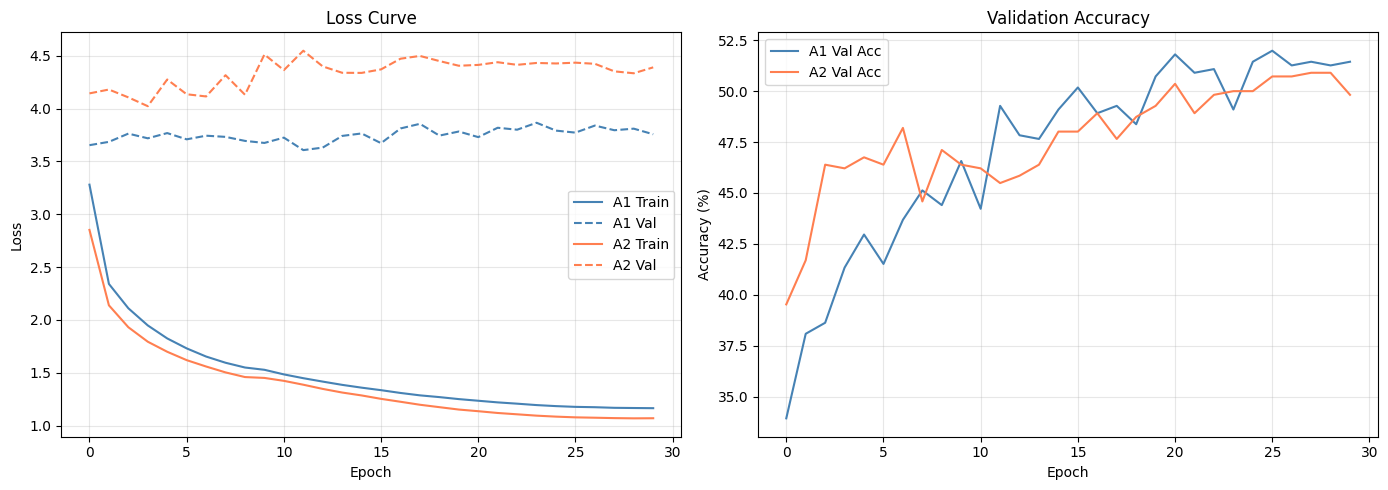

💾 Đã lưu → results/loss_curve.png


In [ ]:
# CELL 20 — Train A1 (LSTM) và A2 (Transformer)

# ── A1: LSTM ──────────────────────────────────────────────────────────────
model_A1   = VQAModel(vocab_size=vocab.n_words, decoder_type='lstm').to(DEVICE)
history_A1 = train_vqa(
    model_A1, train_loader, val_loader, vocab,
    model_name='A1_LSTM',
    resume_path=f'{cfg.PROJECT_DIR}/checkpoints/A1_LSTM_best.pth',
)

# ── A2: Transformer ───────────────────────────────────────────────────────
model_A2   = VQAModel(vocab_size=vocab.n_words, decoder_type='transformer').to(DEVICE)
history_A2 = train_vqa(
    model_A2, train_loader, val_loader, vocab,
    model_name='A2_Transformer',
    resume_path=f'{cfg.PROJECT_DIR}/checkpoints/A2_Transformer_best.pth',
)

plot_history(history_A1, history_A2)

In [ ]:


import torch, json, os

def extend_vocab_and_embedding(model, vocab, new_answers, device):
    """
    Thêm từ mới vào vocab + mở rộng embedding layer của model
    mà không làm mất weights đã train.
    """
    old_size = vocab.n_words

    # 1. Thêm từ mới từ val vào vocab
    for ans in new_answers:
        for word in str(ans).strip().lower().split():
            if word not in vocab.word2idx:
                vocab.word2idx[word] = vocab.n_words
                vocab.idx2word[vocab.n_words] = word
                vocab.n_words += 1

    new_size = vocab.n_words
    added    = new_size - old_size
    print(f'✅ Vocab: {old_size} → {new_size} (+{added} từ mới từ val)')

    if added == 0:
        print('ℹ️  Không có từ mới — vocab đã đầy đủ')
        return

    # 2. Mở rộng embedding + output_proj của decoder
    def extend_decoder(decoder):
        old_emb  = decoder.embedding
        old_proj = decoder.output_proj

        # Embedding mới
        new_emb = torch.nn.Embedding(new_size, old_emb.embedding_dim, padding_idx=0)
        new_emb.weight.data[:old_size] = old_emb.weight.data
        # Khởi tạo ngẫu nhiên cho các từ mới
        torch.nn.init.normal_(new_emb.weight.data[old_size:], mean=0, std=0.01)
        decoder.embedding = new_emb

        # Output projection mới
        new_proj = torch.nn.Linear(old_proj.in_features, new_size)
        new_proj.weight.data[:old_size] = old_proj.weight.data
        new_proj.bias.data[:old_size]   = old_proj.bias.data
        torch.nn.init.normal_(new_proj.weight.data[old_size:], mean=0, std=0.01)
        new_proj.bias.data[old_size:]   = 0
        decoder.output_proj = new_proj

        decoder.to(device)
        print(f'  Decoder embedding: {old_size} → {new_size}')

    extend_decoder(model_A1.decoder)
    extend_decoder(model_A2.decoder)

    # 3. Lưu vocab mới
    vocab.save(f'{cfg.PROJECT_DIR}/checkpoints/vocab.json')
    print(f'💾 Vocab mới đã lưu')

    # 4. Lưu lại checkpoint với vocab mới (overwrite best)
    for model, name in [(model_A1, 'A1_LSTM'), (model_A2, 'A2_Transformer')]:
        ckpt_path = f'{cfg.PROJECT_DIR}/checkpoints/{name}_best.pth'
        if os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, map_location=device)
            ckpt['model_state'] = model.state_dict()
            torch.save(ckpt, ckpt_path)
            print(f'💾 Đã update checkpoint: {name}')


# Chạy extend
extend_vocab_and_embedding(
    model   = model_A1,   # model_A2 cũng được extend bên trong
    vocab   = vocab,
    new_answers = [s['answer'] for s in val_data],
    device  = DEVICE,
)

# Kiểm tra
print(f'\n✅ Vocab size mới: {vocab.n_words}')
print(f'✅ A1 embedding size: {model_A1.decoder.embedding.num_embeddings}')
print(f'✅ A2 embedding size: {model_A2.decoder.embedding.num_embeddings}')

✅ Vocab: 760 → 767 (+7 từ mới từ val)
  Decoder embedding: 760 → 767
  Decoder embedding: 760 → 767
💾 Vocab mới đã lưu
💾 Đã update checkpoint: A1_LSTM
💾 Đã update checkpoint: A2_Transformer

✅ Vocab size mới: 767
✅ A1 embedding size: 767
✅ A2 embedding size: 767


In [ ]:
# CELL 21 — Load Best Checkpoint + Đánh giá Test Set

# A1

ckpt_A1 = torch.load(f'{cfg.PROJECT_DIR}/checkpoints/A1_LSTM_best.pth', map_location=DEVICE)
model_A1.load_state_dict(ckpt_A1['model_state'])
print(f"A1 best epoch: {ckpt_A1['epoch']}  val_acc: {ckpt_A1['val_acc']:.2f}%")
vocab._unk_count = 0
results_A1 = full_evaluate(model_A1, test_loader, vocab, 'A1_LSTM')

# A2
ckpt_A2 = torch.load(f'{cfg.PROJECT_DIR}/checkpoints/A2_Transformer_best.pth', map_location=DEVICE)
model_A2.load_state_dict(ckpt_A2['model_state'])
print(f"A2 best epoch: {ckpt_A2['epoch']}  val_acc: {ckpt_A2['val_acc']:.2f}%")
vocab._unk_count = 0
results_A2 = full_evaluate(model_A2, test_loader, vocab, 'A2_Transformer')

A1 best epoch: 26  val_acc: 51.99%
⚠️  Tổng số lần gặp <UNK>: 17


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



 KẾT QUẢ: A1_LSTM
  VQA Accuracy (exact match) : 47.43%
  BLEU-1                     : 48.58
  BLEU-2                     : 38.38
  ROUGE-L                    : 64.60
  METEOR                     : 43.08
  BERTScore F1               : 73.68

--- Accuracy theo question_type ---
  attribute           : 24.84%  (40/161)
  counting            : 15.00%  (9/60)
  open                : 3.85%  (1/26)
  recognition         : 66.67%  (44/66)
  spatial             : 1.67%  (1/60)
  yes/no              : 86.26%  (182/211)

--- 5 MẪU PREDICT ---
  ✅ Pred: 'bánh bèo'
       Gold: 'bánh bèo'
  ✅ Pred: 'màu sắc chủ đạo là màu trắng'
       Gold: 'màu sắc chủ đạo là màu trắng'
  ❌ Pred: 'có'
       Gold: 'không'
  ✅ Pred: 'có'
       Gold: 'có'
  ❌ Pred: 'trên đĩa'
       Gold: 'trong chén'

💾 Kết quả → /content/drive/MyDrive/VQA_A/results/A1_LSTM_results.json
A2 best epoch: 28  val_acc: 50.90%
⚠️  Tổng số lần gặp <UNK>: 17


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



 KẾT QUẢ: A2_Transformer
  VQA Accuracy (exact match) : 47.77%
  BLEU-1                     : 51.31
  BLEU-2                     : 41.24
  ROUGE-L                    : 66.57
  METEOR                     : 45.40
  BERTScore F1               : 75.30

--- Accuracy theo question_type ---
  attribute           : 22.98%  (37/161)
  counting            : 21.67%  (13/60)
  open                : 0.00%  (0/26)
  recognition         : 63.64%  (42/66)
  spatial             : 1.67%  (1/60)
  yes/no              : 88.15%  (186/211)

--- 5 MẪU PREDICT ---
  ✅ Pred: 'bánh bèo'
       Gold: 'bánh bèo'
  ❌ Pred: 'màu sắc chủ đạo là trắng và vàng'
       Gold: 'màu sắc chủ đạo là màu trắng'
  ❌ Pred: 'có'
       Gold: 'không'
  ✅ Pred: 'có'
       Gold: 'có'
  ❌ Pred: 'trên đĩa'
       Gold: 'trong chén'

💾 Kết quả → /content/drive/MyDrive/VQA_A/results/A2_Transformer_results.json


In [ ]:
# CELL 22 — Debug: xem 10 cặp predict vs reference của A2

model_A2.eval()
with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue
        images         = batch['image'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        logits   = model_A2(images, input_ids, attention_mask, teacher_forcing=False)
        pred_ids = logits.argmax(dim=-1)

        for i in range(min(10, len(pred_ids))):
            pred = vocab.decode(pred_ids[i].tolist())
            gold = batch['answer_text'][i].strip().lower()
            # [FIX] Truy cập trực tiếp batch['question_type'] (luôn tồn tại)
            qt   = batch['question_type'][i]
            print(f'[{qt}]')
            print(f'  Pred: {repr(pred)}')
            print(f'  Gold: {repr(gold)}')
            print()
        break

[recognition]
  Pred: 'bánh bèo'
  Gold: 'bánh bèo'




📊 BẢNG SO SÁNH A1 vs A2
               VQA Acc (%)   BLEU-1   BLEU-2 ROUGE-L  METEOR BERTScore F1
Model                                                                    
A1 LSTM              47.43  48.5773  38.3771  0.6460  0.4308       0.7368
A2 Transformer       47.77  51.3065  41.2370  0.6657  0.4540       0.7530


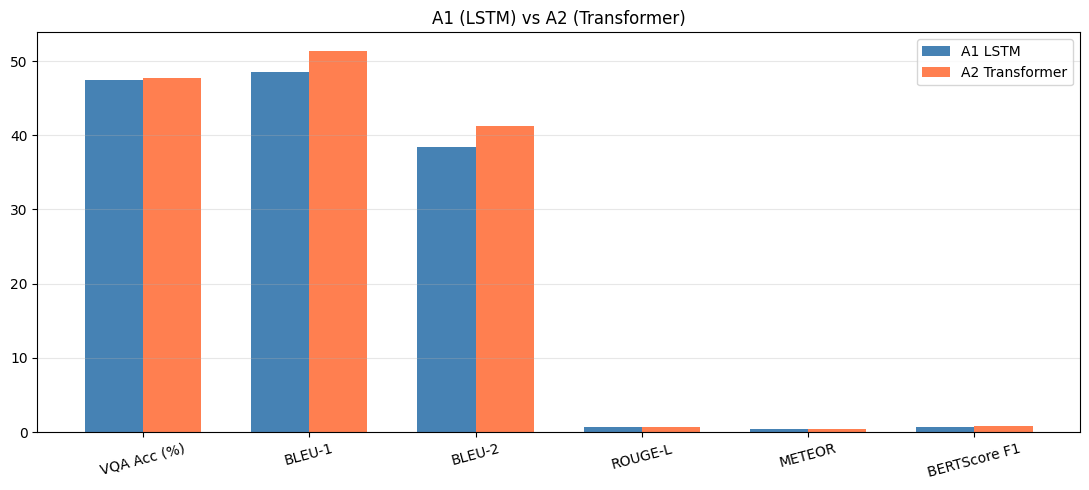

💾 Đã lưu → results/comparison_A1_A2.png


In [ ]:
# CELL 23 — So sánh A1 vs A2

metrics = ['vqa_accuracy', 'bleu1', 'bleu2', 'rouge_l', 'meteor', 'bertscore_f1']
labels  = ['VQA Acc (%)', 'BLEU-1', 'BLEU-2', 'ROUGE-L', 'METEOR', 'BERTScore F1']

rows = []
for r, name in [(results_A1, 'A1 LSTM'), (results_A2, 'A2 Transformer')]:
    row = {'Model': name}
    for m, l in zip(metrics, labels):
        val = r[m]
        row[l] = f'{val*100:.2f}' if m == 'vqa_accuracy' else f'{val:.4f}'
    rows.append(row)

df = pd.DataFrame(rows).set_index('Model')
print('\n📊 BẢNG SO SÁNH A1 vs A2')
print(df.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x     = range(len(labels))
width = 0.35

vals_A1 = [results_A1[m] * (100 if m == 'vqa_accuracy' else 1) for m in metrics]
vals_A2 = [results_A2[m] * (100 if m == 'vqa_accuracy' else 1) for m in metrics]

ax.bar([i - width/2 for i in x], vals_A1, width, label='A1 LSTM',       color='steelblue')
ax.bar([i + width/2 for i in x], vals_A2, width, label='A2 Transformer', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=15)
ax.set_title('A1 (LSTM) vs A2 (Transformer)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.PROJECT_DIR}/results/comparison_A1_A2.png', dpi=150)
plt.show()
print('💾 Đã lưu → results/comparison_A1_A2.png')

In [ ]:
# CELL 24 — Inference thử với 1 ảnh

def predict_single(model, image_input, question, tokenizer, vocab):
    """image_input: đường dẫn file (str) hoặc PIL Image"""
    model.eval()
    transform = get_transform(is_train=False)

    if isinstance(image_input, str):
        img = Image.open(image_input).convert('RGB')
    else:
        img = image_input.convert('RGB')

    img  = transform(img).unsqueeze(0).to(DEVICE)
    enc  = tokenizer(question, max_length=cfg.MAX_Q_LEN,
                     padding='max_length', truncation=True, return_tensors='pt')
    input_ids      = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    with torch.no_grad():
        logits   = model(img, input_ids, attention_mask, teacher_forcing=False)
        pred_ids = logits.argmax(dim=-1)[0]
        answer   = vocab.decode(pred_ids.tolist())

    print(f'❓ Câu hỏi  : {question}')
    print(f'✅ Đáp án   : {answer}')
    return answer


# [FIX BUG #C] sample['image_path'] luôn tồn tại (add_path được gọi ở Cell 7)
sample      = test_data[0]
image_path  = sample['image_path']   # tuyệt đối, không còn KeyError
question    = sample['question']
gold_answer = sample['answer']

print('=== A1 LSTM ===')
predict_single(model_A1, image_path, question, tokenizer, vocab)
print(f'🎯 Ground truth: {gold_answer}')

print('\n=== A2 Transformer ===')
predict_single(model_A2, image_path, question, tokenizer, vocab)
print(f'🎯 Ground truth: {gold_answer}')

=== A1 LSTM ===
❓ Câu hỏi  : trong ảnh là món ăn gì
✅ Đáp án   : bánh bèo
🎯 Ground truth: bánh bèo

=== A2 Transformer ===
❓ Câu hỏi  : trong ảnh là món ăn gì
✅ Đáp án   : bánh bèo
🎯 Ground truth: bánh bèo


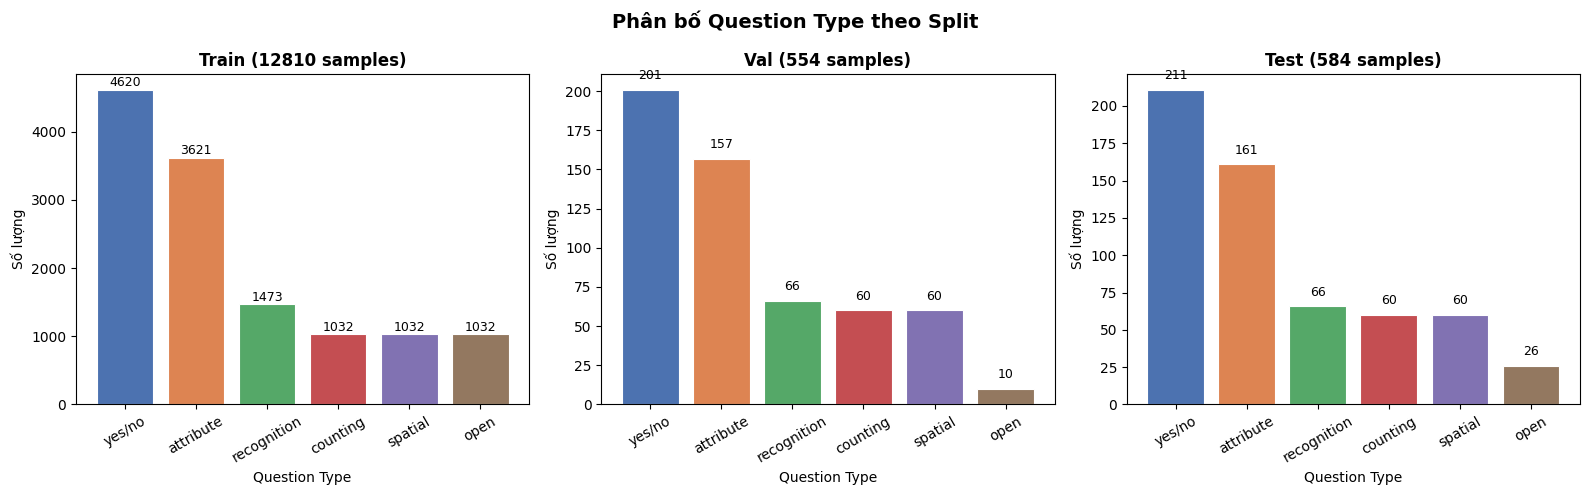

💾 Đã lưu → results/viz_question_type_dist.png


In [ ]:
# CELL 25 — Visualize: Phân bố question_type (Train/Val/Test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phân bố Question Type theo Split', fontsize=14, fontweight='bold')

for ax, (data, name) in zip(axes, [(train_data, 'Train'), (val_data, 'Val'), (test_data, 'Test')]):
    qt_counts = Counter(s.get('question_type', 'unknown') for s in data)
    labels    = [k for k, _ in qt_counts.most_common()]
    values    = [qt_counts[k] for k in labels]
    colors    = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
    bars = ax.bar(labels, values, color=colors[:len(labels)], edgecolor='white', linewidth=0.8)
    ax.set_title(f'{name} ({len(data)} samples)', fontweight='bold')
    ax.set_xlabel('Question Type')
    ax.set_ylabel('Số lượng')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{cfg.PROJECT_DIR}/results/viz_question_type_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu → results/viz_question_type_dist.png')

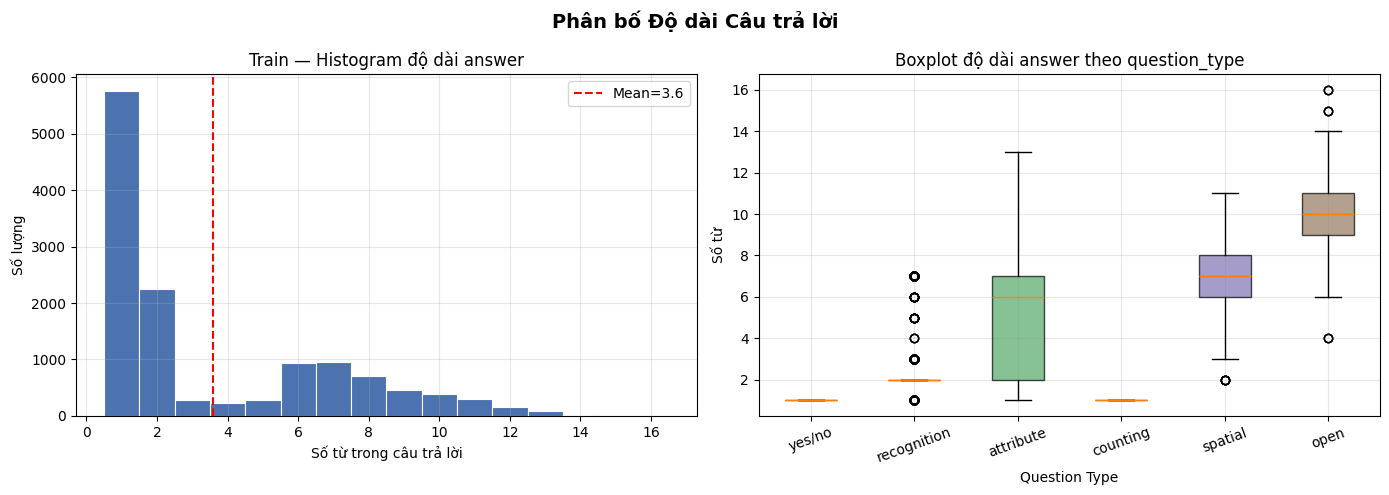

💾 Đã lưu → results/viz_answer_length.png


In [ ]:
# CELL 26 — Visualize: Phân bố độ dài câu trả lời

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân bố Độ dài Câu trả lời', fontsize=14, fontweight='bold')

# Histogram độ dài
all_lens   = [len(str(s['answer']).split()) for s in train_data]
axes[0].hist(all_lens, bins=range(1, max(all_lens)+2), color='#4C72B0',
             edgecolor='white', linewidth=0.8, align='left')
axes[0].set_title('Train — Histogram độ dài answer')
axes[0].set_xlabel('Số từ trong câu trả lời')
axes[0].set_ylabel('Số lượng')
axes[0].axvline(np.mean(all_lens), color='red', linestyle='--',
                label=f'Mean={np.mean(all_lens):.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot theo question_type
qt_lens = defaultdict(list)
for s in train_data:
    qt_lens[s.get('question_type', 'unknown')].append(
        len(str(s['answer']).split())
    )
qt_order = ['yes/no', 'recognition', 'attribute', 'counting', 'spatial', 'open']
data_box  = [qt_lens[qt] for qt in qt_order if qt in qt_lens]
labels_box = [qt for qt in qt_order if qt in qt_lens]
bp = axes[1].boxplot(data_box, labels=labels_box, patch_artist=True)
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Boxplot độ dài answer theo question_type')
axes[1].set_xlabel('Question Type')
axes[1].set_ylabel('Số từ')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{cfg.PROJECT_DIR}/results/viz_answer_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu → results/viz_answer_length.png')

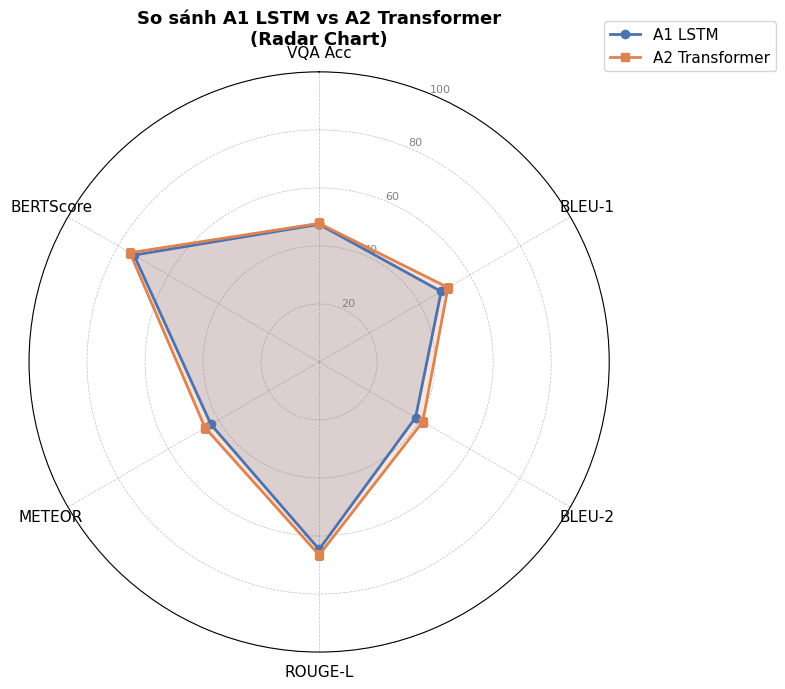

💾 Đã lưu → results/viz_radar_chart.png


In [ ]:
# CELL 28 — Visualize: Radar Chart so sánh A1 vs A2

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics_radar  = ['VQA Acc', 'BLEU-1', 'BLEU-2', 'ROUGE-L', 'METEOR', 'BERTScore']
values_A1_raw  = [
    results_A1['vqa_accuracy'] * 100,
    results_A1['bleu1'],
    results_A1['bleu2'],
    results_A1['rouge_l'] * 100,
    results_A1['meteor'] * 100,
    results_A1['bertscore_f1'] * 100,
]
values_A2_raw  = [
    results_A2['vqa_accuracy'] * 100,
    results_A2['bleu1'],
    results_A2['bleu2'],
    results_A2['rouge_l'] * 100,
    results_A2['meteor'] * 100,
    results_A2['bertscore_f1'] * 100,
]

N      = len(metrics_radar)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

v_A1 = values_A1_raw + values_A1_raw[:1]
v_A2 = values_A2_raw + values_A2_raw[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8, color='grey')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

ax.plot(angles, v_A1, 'o-', linewidth=2, color='#4C72B0', label='A1 LSTM')
ax.fill(angles, v_A1, alpha=0.2, color='#4C72B0')

ax.plot(angles, v_A2, 's-', linewidth=2, color='#DD8452', label='A2 Transformer')
ax.fill(angles, v_A2, alpha=0.2, color='#DD8452')

ax.set_title('So sánh A1 LSTM vs A2 Transformer\n(Radar Chart)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig(f'{cfg.PROJECT_DIR}/results/viz_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu → results/viz_radar_chart.png')

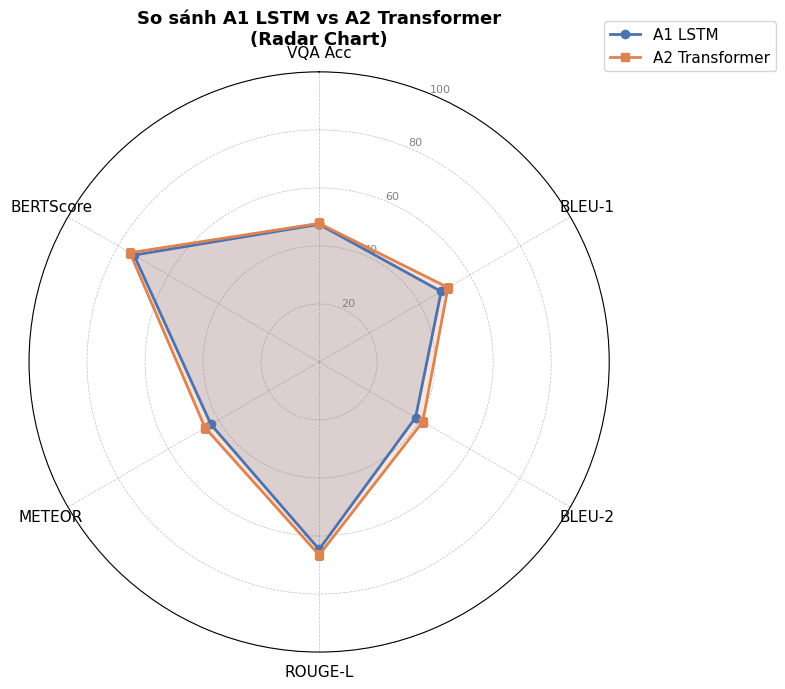

💾 Đã lưu → results/viz_radar_chart.png


In [ ]:
# CELL 28 — Visualize: Radar Chart so sánh A1 vs A2

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics_radar  = ['VQA Acc', 'BLEU-1', 'BLEU-2', 'ROUGE-L', 'METEOR', 'BERTScore']
values_A1_raw  = [
    results_A1['vqa_accuracy'] * 100,
    results_A1['bleu1'],
    results_A1['bleu2'],
    results_A1['rouge_l'] * 100,
    results_A1['meteor'] * 100,
    results_A1['bertscore_f1'] * 100,
]
values_A2_raw  = [
    results_A2['vqa_accuracy'] * 100,
    results_A2['bleu1'],
    results_A2['bleu2'],
    results_A2['rouge_l'] * 100,
    results_A2['meteor'] * 100,
    results_A2['bertscore_f1'] * 100,
]

N      = len(metrics_radar)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

v_A1 = values_A1_raw + values_A1_raw[:1]
v_A2 = values_A2_raw + values_A2_raw[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8, color='grey')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

ax.plot(angles, v_A1, 'o-', linewidth=2, color='#4C72B0', label='A1 LSTM')
ax.fill(angles, v_A1, alpha=0.2, color='#4C72B0')

ax.plot(angles, v_A2, 's-', linewidth=2, color='#DD8452', label='A2 Transformer')
ax.fill(angles, v_A2, alpha=0.2, color='#DD8452')

ax.set_title('So sánh A1 LSTM vs A2 Transformer\n(Radar Chart)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig(f'{cfg.PROJECT_DIR}/results/viz_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu → results/viz_radar_chart.png')

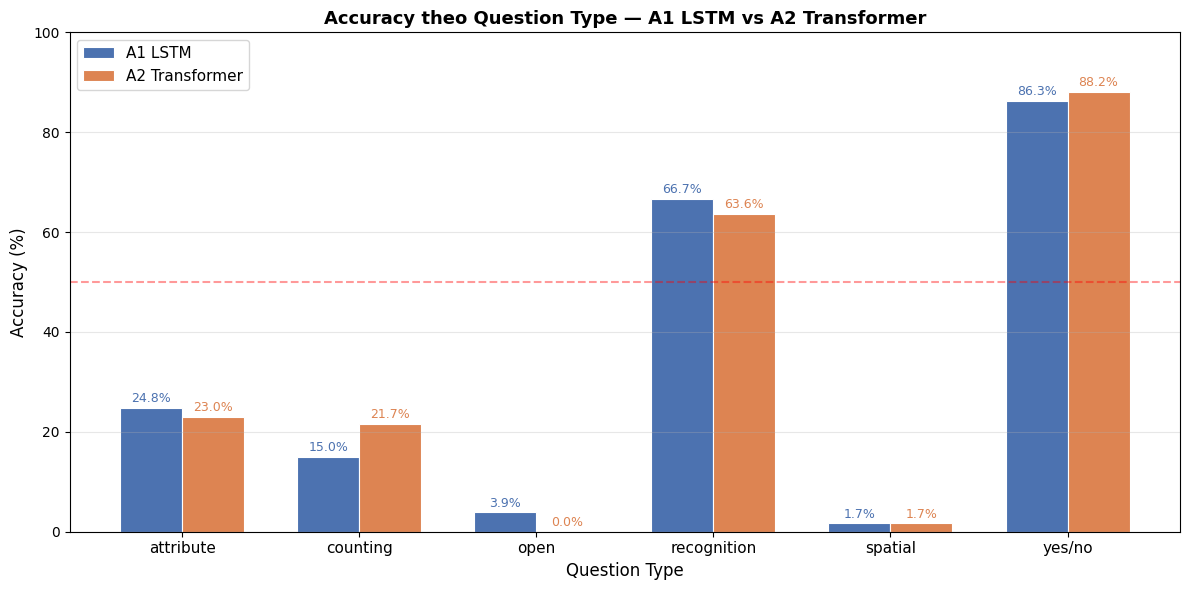

💾 Đã lưu → results/viz_accuracy_by_qtype.png


In [ ]:
# CELL 29 — Visualize: Accuracy theo question_type (A1 vs A2)

qt_results = {
    'attribute':   {'A1': 24.84, 'A2': 22.98},
    'counting':    {'A1': 15.00, 'A2': 21.67},
    'open':        {'A1':  3.85, 'A2':  0.00},
    'recognition': {'A1': 66.67, 'A2': 63.64},
    'spatial':     {'A1':  1.67, 'A2':  1.67},
    'yes/no':      {'A1': 86.26, 'A2': 88.15},
}

qt_labels = list(qt_results.keys())
vals_A1   = [qt_results[qt]['A1'] for qt in qt_labels]
vals_A2   = [qt_results[qt]['A2'] for qt in qt_labels]

x     = np.arange(len(qt_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, vals_A1, width, label='A1 LSTM',
               color='#4C72B0', edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + width/2, vals_A2, width, label='A2 Transformer',
               color='#DD8452', edgecolor='white', linewidth=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='#4C72B0')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='#DD8452')

ax.set_xlabel('Question Type', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy theo Question Type — A1 LSTM vs A2 Transformer',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(qt_labels, fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.4, label='50% baseline')

plt.tight_layout()
plt.savefig(f'{cfg.PROJECT_DIR}/results/viz_accuracy_by_qtype.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu → results/viz_accuracy_by_qtype.png')